In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.linalg import eig


In [8]:
#参数 SESARs
dela = 1
chaodaojiao = 0
a=1
af =20
mu = 0
tc=15

#右边S
tr=30
hx=0   #0.5
hz=2 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#左边N
tl=25
mx=0 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=0


Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,t,renyixiang=0):
    if weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,tl)
H_L_right_to_left_hop=H_hop(af2*af,tl)

#中间矩阵信息
H_center_to_L=H_hop(af2*af,tl)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,tl)
H_center_right_to_left_hop=H_hop(af2*a,tl)

H_R_to_center=H_hop(0,tc)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,tr)
H_R_right_to_left_hop=H_hop(af,tr)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center




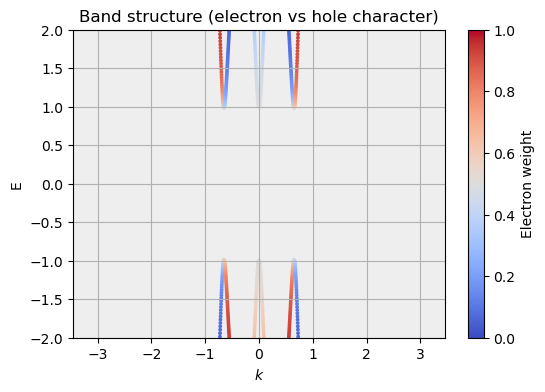

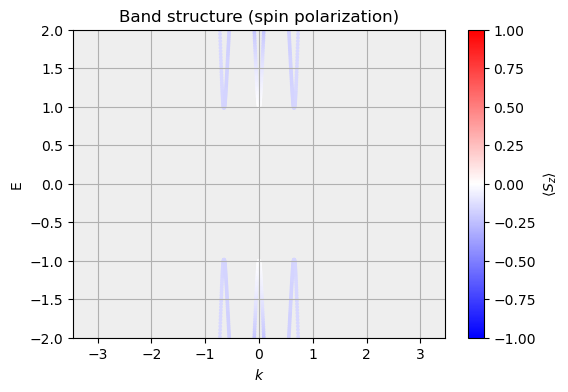

In [10]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [sz, np.zeros((2,2))],
    [np.zeros((2,2)), 1*sz]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
delta=dela
plt.ylim(-delta*2,delta*2)
#plt.ylim(-2,2)
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
plt.ylim(-delta*2,delta*2)
#plt.xlim(-1,1)
#plt.xlim(-dela,dela)
plt.show()



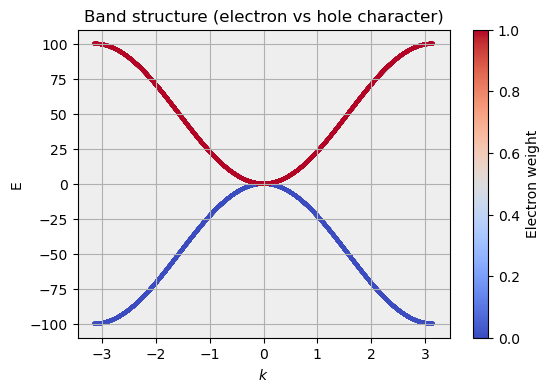

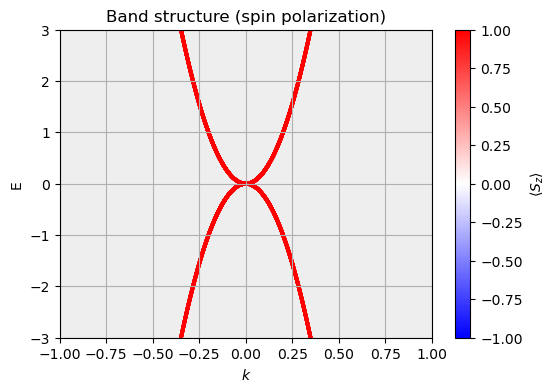

In [11]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [s0, np.zeros((2,2))],
    [np.zeros((2,2)), s0]
])

ks = np.linspace(-np.pi, np.pi, 20001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_l, T_l)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
delta=dela
plt.ylim(-3*delta,3*delta)
plt.xlim(-1,1)
plt.show()

